In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import tensorflow as tf 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Load the preprocessed data
data = pd.read_csv('../Clustering_Analysis/dataset_with_clusters.csv')
data.head()

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,MonthlyCharges,Churn,InternetService_Fiber optic,Contract_One year,Contract_Two year,Cluster
0,0,0,0,-1.277445,0,0,-1.321350,1,False,False,False,2
1,1,0,0,0.351370,1,0,-1.321350,0,False,True,False,3
2,0,0,1,0.799294,1,0,-1.520755,0,False,False,False,3
3,0,0,0,-1.277445,1,0,0.373593,1,False,True,False,1
4,1,0,0,1.410099,1,0,-0.457261,0,True,False,False,3


In [ ]:
# Splitting the data set into training and testing sets\

tf.random.set_seed(42)
np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(data.drop('Churn', axis=1), data['Churn'], test_size=0.2, random_state=42, stratify=data['Churn'])

In [4]:
# Checking shape and distribution
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training set class distribution:\n", y_train.value_counts(normalize=True))
print("Testing set class distribution:\n", y_test.value_counts(normalize=True))

Training set shape: (5634, 11)
Testing set shape: (1409, 11)
Training set class distribution:
 Churn
0    0.733404
1    0.266596
Name: proportion, dtype: float64
Testing set class distribution:
 Churn
0    0.739532
1    0.260468
Name: proportion, dtype: float64


In [5]:
# Scaling the features
scaler = StandardScaler()

number_cols = ['tenure', 'MonthlyCharges']

# Fit the scaler on the training data and transform both training and testing data
X_train[number_cols] = scaler.fit_transform(X_train[number_cols])
X_test[number_cols] = scaler.transform(X_test[number_cols])

print(X_train.head(),"\n")
print(X_train[['tenure', 'MonthlyCharges']].describe())

      gender  SeniorCitizen  Dependents    tenure  PhoneService  \
2142       1              0           1  1.284046             1   
1623       1              0           0 -0.100769             1   
6074       1              0           0 -1.119016             1   
1362       0              0           1  1.446966             1   
6754       1              0           0 -0.956096             0   

      MultipleLines  MonthlyCharges  InternetService_Fiber optic  \
2142              0        1.467486                        False   
1623              1       -1.482476                         True   
6074              0        0.970301                        False   
1362              0        1.467486                         True   
6754              1       -0.653835                        False   

      Contract_One year  Contract_Two year  Cluster  
2142               True              False        0  
1623              False               True        2  
6074              False   

In [ ]:
# Creating an ANN Model
model = Sequential([
    Dense(128, activation="elu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.25),

    Dense(64, activation="elu"),
    BatchNormalization(),
    Dropout(0.20),

    Dense(16, activation="elu"),
    Dropout(0.15),

    Dense(1, activation="sigmoid")
])

/opt/homebrew/Caskroom/miniconda/base/envs/ACS-WILDA-Py3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-04 16:53:27.270052: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-04 16:53:27.270232: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-04 16:53:27.270250: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-04 16:53:27.270542: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-04 16:53:27.270564: I tensorflow/core/common_runtime/pluggable_device/pl

In [ ]:
# Build class weights to handle class imbalance
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))

In [ ]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model with early stopping

early_stop = EarlyStopping(monitor="val_auc", mode="max", patience=8, restore_best_weights=True)

history = model.fit(
X_train, y_train,
validation_split=0.2,
epochs=60,
batch_size=32,
callbacks=[early_stop],
verbose=1
)

Epoch 1/100


2026-04-04 16:53:27.990425: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7504 - loss: 0.5134 - val_accuracy: 0.7986 - val_loss: 0.4424
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7735 - loss: 0.4838 - val_accuracy: 0.7941 - val_loss: 0.4339
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7750 - loss: 0.4695 - val_accuracy: 0.7995 - val_loss: 0.4327
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7750 - loss: 0.4664 - val_accuracy: 0.7995 - val_loss: 0.4332
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7810 - loss: 0.4606 - val_accuracy: 0.8021 - val_loss: 0.4330
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7819 - loss: 0.4620 - val_accuracy: 0.8012 - val_loss: 0.4368
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7850 - loss: 0.4649 - val_accuracy: 0.7986 - val_loss: 0.4310
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7810 - loss: 0.4606 - val_accuracy

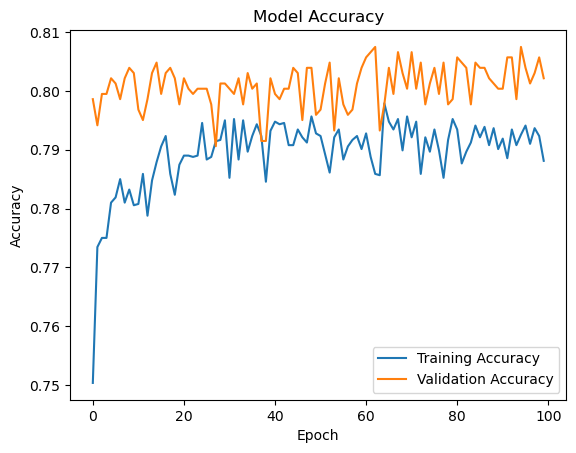

In [9]:
# Training accuray and Validation accuracy
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show() 

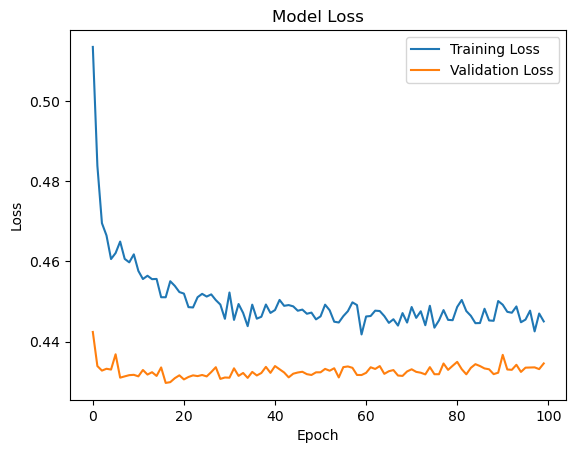

In [10]:
# Loss curve
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy, test_auc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test AUC: {test_auc:.4f}")

y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Loss: 0.4603
Test Accuracy: 0.7658
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.90      0.85      1042
           1       0.58      0.38      0.46       367

    accuracy                           0.77      1409
   macro avg       0.69      0.64      0.65      1409
weighted avg       0.75      0.77      0.75      1409

Confusion Matrix:
 [[941 101]
 [229 138]]


In [12]:
# Plotting Seaborn Confusion Matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
# ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show() 